# Democracy Dataset Processing

## Polity

In [1472]:
import logging

import country_converter as coco
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

df = pd.read_excel("p5v2018.xls")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")


Shape: 17,574 rows × 37 columns


### Dataset Coverage

In [1473]:
year_min = df["year"].min()
year_max = df["year"].max()
n_countries = df["country"].nunique()

# Note: 2019–2020 contain only the United States (late addition to the dataset)
world_year_max = df[df["country"] != "United States"]["year"].max()

cpy = df.groupby("year")["country"].count()
early = df.groupby("country")["year"].min()
p5_revised = df[df["p5"] == 1]["country"].nunique()

print(f"Years covered        : {year_min} – {year_max}")
print(f"  World coverage ends: {world_year_max} (2019–2020 = United States only)")
print(f"Unique countries     : {n_countries}")
print(f"Country-year obs     : {len(df):,}")
print(f"Countries per year   : min {cpy.min()} ({cpy.idxmin()})  /  max {cpy.max()} ({cpy.idxmax()})")
print(f"Coded from 1800      : {(early == 1800).sum()} countries")
print(f"Coded after 1800     : {(early > 1800).sum()} countries (from year of independence)")
print(f"Polity5-revised (p5=1): {p5_revised} / {n_countries} countries")


Years covered        : 1776 – 2020
  World coverage ends: 2018 (2019–2020 = United States only)
Unique countries     : 195
Country-year obs     : 17,574
Countries per year   : min 1 (1776)  /  max 168 (2011)
Coded from 1800      : 21 countries
Coded after 1800     : 173 countries (from year of independence)
Polity5-revised (p5=1): 84 / 195 countries


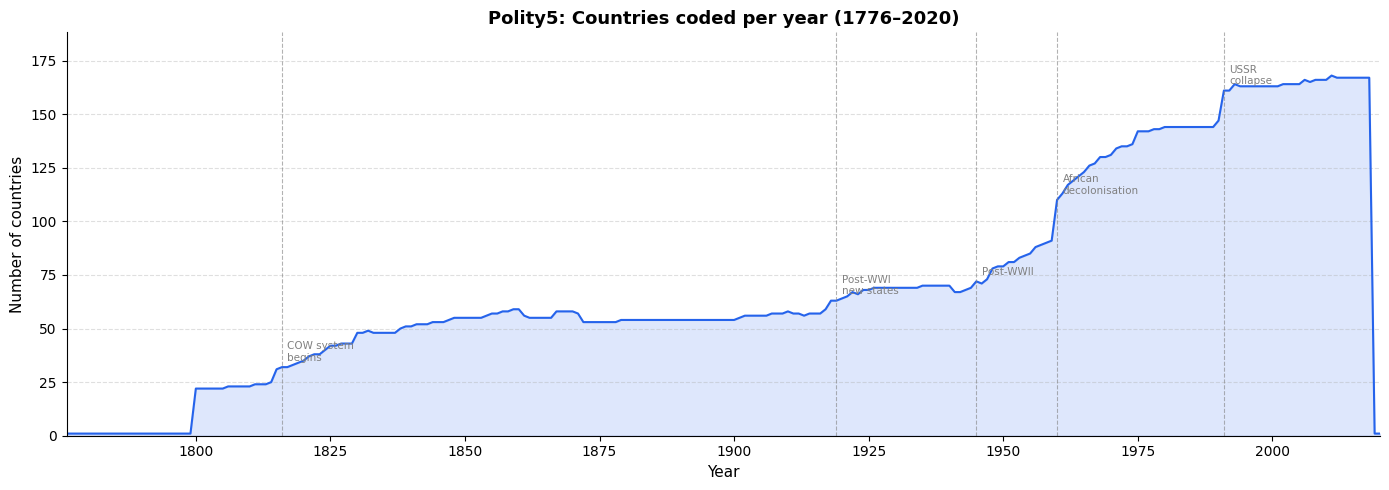

In [1474]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(cpy.index, cpy.values, alpha=0.15, color="#2563eb")
ax.plot(cpy.index, cpy.values, color="#2563eb", linewidth=1.5)

milestones = {
    1816: "COW system\nbegins",
    1919: "Post-WWI\nnew states",
    1945: "Post-WWII",
    1960: "African\ndecolonisation",
    1991: "USSR\ncollapse",
}
for yr, label in milestones.items():
    y = cpy.get(yr, cpy.iloc[0])
    ax.axvline(yr, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.text(yr + 1, y + 2, label, fontsize=7.5, color="gray", va="bottom")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of countries", fontsize=11)
ax.set_title("Polity5: Countries coded per year (1776–2020)", fontsize=13, fontweight="bold")
ax.set_xlim(cpy.index.min(), cpy.index.max())
ax.set_ylim(0, cpy.max() * 1.12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


### Scope

In [1475]:
df = df[(df["year"] >= 1971) & (df["year"] <= 2018)]
print(f"Shape after scope filter: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
print(f"Unique countries: {df['country'].nunique()}")

Shape after scope filter: 7,451 rows × 37 columns
Years: 1971 – 2018
Unique countries: 180


### Identifiers

Whenever I can, I map the COW code to the ISO3 (ISO only considers current existing countries, if the country doesn't exist, it won't be mapped)

In [1476]:
logging.getLogger('country_converter').setLevel(logging.ERROR)

cc = coco.CountryConverter()

def to_iso3(name):
    result = cc.convert(name, src="name_short", to="ISO3", not_found=None)
    # country_converter may return the original name instead of None when it
    # cannot find a proper ISO3 — treat anything that isn't a 3-letter
    # uppercase code as unresolved.
    if isinstance(result, str) and len(result) == 3 and result.isupper():
        return result
    return None

# ccode is the COW numeric code; country_converter has no direct COW mapping,
# so we resolve ISO3 via the country name field.
country_to_iso3 = {name: to_iso3(name) for name in df["country"].unique()}

df["iso3"] = df["country"].map(country_to_iso3)

missing = df[df["iso3"].isna()]["country"].unique()
print(f"Mapped to ISO3   : {df['iso3'].notna().sum():,} rows")
print(f"No ISO3 found    : {df['iso3'].isna().sum():,} rows")
if len(missing):
    print(f"\nCountries without ISO3 ({len(missing)}):")
    for c in sorted(missing):
        ccode_val = df[df["country"] == c]["ccode"].iloc[0]
        print(f"  {c!r}  (ccode={ccode_val})")

Mapped to ISO3   : 6,720 rows
No ISO3 found    : 731 rows

Countries without ISO3 (27):
  'Bosnia'  (ccode=346)
  'Cape Verde'  (ccode=402)
  'Congo Brazzaville'  (ccode=484)
  'Congo Kinshasa'  (ccode=490)
  'Congo-Brazzaville'  (ccode=484)
  "Cote D'Ivoire"  (ccode=437)
  'Czech Republic'  (ccode=316)
  'Czechoslovakia'  (ccode=315)
  'Germany East'  (ccode=265)
  'Germany West'  (ccode=260)
  'Ivory Coast'  (ccode=437)
  'Korea North'  (ccode=731)
  'Korea South'  (ccode=732)
  'Macedonia'  (ccode=343)
  'Myanmar (Burma)'  (ccode=775)
  'Serbia and Montenegro'  (ccode=347)
  'Slovak Republic'  (ccode=317)
  'South Vietnam'  (ccode=817)
  'Sudan-North'  (ccode=626)
  'Swaziland'  (ccode=572)
  'Timor Leste'  (ccode=860)
  'Turkey'  (ccode=640)
  'USSR'  (ccode=364)
  'Vietnam North'  (ccode=816)
  'Yemen North'  (ccode=678)
  'Yemen South'  (ccode=680)
  'Yugoslavia'  (ccode=347)


Now I hardcode values for those countries that aren't mapped to the country they unified to, or the main country after separation

In [1477]:
MANUAL_ISO3 = {
    "Bosnia":                 "BIH",
    "Cape Verde":             "CPV",
    "Congo-Brazzaville":      "COG",
    "Congo Brazzaville":      "COG",
    "Czechoslovakia":         "CZE",
    "Czech Republic":         "CZE",
    "Vietnam North":          "VNM",
    "Timor Leste":            "TLS",
    "Germany East":           "DEU",
    "Germany West":           "DEU",
    "Cote D'Ivoire":          "CIV",
    "Ivory Coast":            "CIV",
    "Macedonia":              "MKD",
    "Myanmar (Burma)":        "MMR",
    "Korea North":            "PRK",
    "Korea South":            "KOR",
    "South Vietnam":          "VNM",
    "Sudan-North":            "SDN",
    "Slovak Republic":        "SVK",
    "Swaziland":              "SWZ",
    "Turkey":                 "TUR",
    "UAE":                    "ARE",
    "USSR":                   "RUS",
    "Yemen North":            "YEM",
    "Yugoslavia":             "SRB",
    "Serbia and Montenegro":  "SRB",
    "Yemen South":            "YEM",
    "Congo Kinshasa":         "COD",
}

df["iso3"] = df.apply(
    lambda r: MANUAL_ISO3.get(r["country"], r["iso3"]), axis=1
)

still_missing = df[df["iso3"].isna()]["country"].unique()
print(f"Mapped to ISO3   : {df['iso3'].notna().sum():,} rows")
print(f"No ISO3 found    : {df['iso3'].isna().sum():,} rows")
if len(still_missing):
    print(f"\nStill missing ({len(still_missing)}):")
    for c in sorted(still_missing):
        print(f"  {c!r}")

Mapped to ISO3   : 7,451 rows
No ISO3 found    : 0 rows


In [1478]:
df = df.rename(columns={"country": "orig_country", "ccode": "orig_ccode", "iso3": "curr_iso3"})

df["curr_country"] = df["curr_iso3"].map(
    lambda iso3: cc.convert(iso3, src="ISO3", to="name_short")
)

print(df[["orig_country", "orig_ccode", "curr_iso3", "curr_country"]].head())

    orig_country  orig_ccode curr_iso3 curr_country
171  Afghanistan         700       AFG  Afghanistan
172  Afghanistan         700       AFG  Afghanistan
173  Afghanistan         700       AFG  Afghanistan
174  Afghanistan         700       AFG  Afghanistan
175  Afghanistan         700       AFG  Afghanistan


### Country changes within scope (1971–2018)

Each historical country name is mapped to the ISO3 of its successor or current equivalent state.

#### Unifications
| Historical countries | Unified into | Year | Notes |
|---|---|---|---|
| Germany East (1971–1990) + Germany West (1971–1990) | Germany / DEU (1990–2018) | 1990 | Both predecessors and unified Germany share the 1990 observation |
| Vietnam North + South Vietnam | Vietnam (VNM) | 1976 | |
| Yemen North + Yemen South | Yemen (YEM) | 1990 | |

#### Dissolutions → mapped to main successor
| Historical country | Successor (mapped to) | Year | Other successors |
|---|---|---|---|
| USSR | Russia (RUS) | 1991 | 14 independent republics |
| Yugoslavia | Serbia (SRB) | 1992–2006 | Slovenia, Croatia, Bosnia, Macedonia, Montenegro |
| Czechoslovakia | Czech Republic (CZE) | 1993 | Slovakia (SVK) |
| Serbia and Montenegro | Serbia (SRB) | 2006 | Montenegro (MNE) |

#### Secessions
| Historical country | ISO3 | Event |
|---|---|---|
| Bosnia | BIH | Independence from Yugoslavia (1992) |
| Macedonia | MKD | Independence from Yugoslavia (1991) |
| Timor Leste | TLS | Independence from Indonesia (2002) |
| Sudan-North | SDN | South Sudan split off (2011) |

#### Name changes / alternate spellings
| Name in dataset | ISO3 | Current name |
|---|---|---|
| Congo-Brazzaville / Congo Brazzaville | COG | Republic of the Congo |
| Congo Kinshasa | COD | Democratic Republic of the Congo |
| Cote D'Ivoire / Ivory Coast | CIV | Côte d'Ivoire |
| Myanmar (Burma) | MMR | Myanmar |
| Swaziland | SWZ | Eswatini (renamed 2018) |
| Turkey | TUR | Türkiye |
| UAE | ARE | United Arab Emirates |
| Cape Verde | CPV | Cabo Verde |

#### Germany Unification

In [1479]:
df["country"] = df["orig_country"]

In [1480]:
for name in ["Germany East", "Germany West", "Germany"]:
    sub = df[df["orig_country"] == name]["year"]
    print(f"{name}: {sorted(sub.tolist())}")

Germany East: [1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990]
Germany West: [1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990]
Germany: [1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018]


In [1481]:
germany_post = df[(df["orig_country"] == "Germany") & (df["year"] >= 1991)].copy()

east_ext = germany_post.copy()
east_ext["orig_country"] = "Germany East"
east_ext["orig_ccode"] = 265

west_ext = germany_post.copy()
west_ext["orig_country"] = "Germany West"
west_ext["orig_ccode"] = 260

df = pd.concat([
    df[df["orig_country"] != "Germany"],
    east_ext,
    west_ext,
], ignore_index=True).sort_values(["orig_country", "year"])

for name in ["Germany East", "Germany West", "Germany"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Germany East: 1971–2018 (48 rows)
Germany West: 1971–2018 (48 rows)
Germany: not present


#### Vietnam Unification

In [1482]:
for name in ["Vietnam North", "South Vietnam", "Vietnam"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Vietnam North: 1971–1976 (6 rows)
South Vietnam: 1971–1975 (5 rows)
Vietnam: 1976–2018 (43 rows)


In [1483]:
vietnam_unified = df[df["orig_country"] == "Vietnam"]

# Vietnam North ends at 1976 → extend from 1977
north_ext = vietnam_unified[vietnam_unified["year"] >= 1977].copy()
north_ext["orig_country"] = "Vietnam North"
north_ext["orig_ccode"] = 816

# South Vietnam ends at 1975 → extend from 1976
south_ext = vietnam_unified[vietnam_unified["year"] >= 1976].copy()
south_ext["orig_country"] = "South Vietnam"
south_ext["orig_ccode"] = 817

df = pd.concat([
    df[df["orig_country"] != "Vietnam"],
    north_ext,
    south_ext,
], ignore_index=True).sort_values(["orig_country", "year"])

for name in ["Vietnam North", "South Vietnam", "Vietnam"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Vietnam North: 1971–2018 (48 rows)
South Vietnam: 1971–2018 (48 rows)
Vietnam: not present


#### Yemen Unification

In [1484]:
for name in ["Yemen North", "Yemen South", "Yemen"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Yemen North: 1971–1990 (20 rows)
Yemen South: 1971–1990 (20 rows)
Yemen: 1990–2018 (29 rows)


In [1485]:
# Both Yemen North and Yemen South end at 1990; unified Yemen also has a 1990 row.
# Extend both from 1991 onwards, same as Germany.
yemen_post = df[(df["orig_country"] == "Yemen") & (df["year"] >= 1991)].copy()

north_ext = yemen_post.copy()
north_ext["orig_country"] = "Yemen North"
north_ext["orig_ccode"] = 678

south_ext = yemen_post.copy()
south_ext["orig_country"] = "Yemen South"
south_ext["orig_ccode"] = 680

df = pd.concat([
    df[df["orig_country"] != "Yemen"],
    north_ext,
    south_ext,
], ignore_index=True).sort_values(["orig_country", "year"])

for name in ["Yemen North", "Yemen South", "Yemen"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Yemen North: 1971–2018 (48 rows)
Yemen South: 1971–2018 (48 rows)
Yemen: not present


#### USSR Dissolution

In [1486]:
for name in ["USSR", "Russia", "Armenia", "Azerbaijan", "Belarus", "Estonia", "Georgia",
             "Kazakhstan", "Kyrgyzstan", "Latvia", "Lithuania", "Moldova",
             "Tajikistan", "Turkmenistan", "Ukraine", "Uzbekistan"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

USSR: 1971–1991 (21 rows)
Russia: 1992–2018 (27 rows)
Armenia: 1991–2018 (28 rows)
Azerbaijan: 1991–2018 (28 rows)
Belarus: 1991–2018 (28 rows)
Estonia: 1991–2018 (28 rows)
Georgia: 1991–2018 (28 rows)
Kazakhstan: 1991–2018 (28 rows)
Kyrgyzstan: 1991–2018 (28 rows)
Latvia: 1991–2018 (28 rows)
Lithuania: 1991–2018 (28 rows)
Moldova: 1991–2018 (28 rows)
Tajikistan: 1991–2018 (28 rows)
Turkmenistan: 1991–2018 (28 rows)
Ukraine: 1991–2018 (28 rows)
Uzbekistan: 1991–2018 (28 rows)


In [1487]:
ussr_rows = df[df["orig_country"] == "USSR"].copy()

# All 15 successor states with their independent-period orig_ccode and ISO3.
# Russia is included here only for the orig_country/orig_ccode update step below;
# its pre-1992 rows are already covered by the original USSR rows (curr_iso3="RUS").
SOVIET_SUCCESSORS = {
    "Armenia":     ("ARM", 371),
    "Azerbaijan":  ("AZE", 373),
    "Belarus":     ("BLR", 370),
    "Estonia":     ("EST", 366),
    "Georgia":     ("GEO", 372),
    "Kazakhstan":  ("KAZ", 705),
    "Kyrgyzstan":  ("KGZ", 703),
    "Latvia":      ("LVA", 367),
    "Lithuania":   ("LTU", 368),
    "Moldova":     ("MDA", 359),
    "Russia":      ("RUS", 365),
    "Tajikistan":  ("TJK", 702),
    "Turkmenistan":("TKM", 701),
    "Ukraine":     ("UKR", 369),
    "Uzbekistan":  ("UZB", 704),
}

# Build pre-independence extensions (USSR rows before each state's first year)
extensions = []
for successor, (iso3, ccode) in SOVIET_SUCCESSORS.items():
    if successor == "Russia":
        continue  # already covered by original USSR rows (curr_iso3="RUS")
    first_year = df[df["orig_country"] == successor]["year"].min()
    ext = ussr_rows[ussr_rows["year"] < first_year].copy()
    ext["curr_iso3"] = iso3
    ext["curr_country"] = cc.convert(iso3, src="ISO3", to="name_short")
    extensions.append(ext)

df = pd.concat([df] + extensions, ignore_index=True)

# Set orig_country/orig_ccode to USSR for all successor-state rows
# (both the newly added pre-independence rows and the existing independent rows)
successor_names = set(SOVIET_SUCCESSORS.keys())
mask = df["orig_country"].isin(successor_names)
df.loc[mask, "orig_country"] = "USSR"
df.loc[mask, "orig_ccode"] = 364

df = df.sort_values(["curr_iso3", "year"])

# Verify
for successor, (iso3, _) in SOVIET_SUCCESSORS.items():
    sub = df[df["curr_iso3"] == iso3]
    orig_vals = sub["orig_country"].unique().tolist()
    print(f"{successor} ({iso3}): {sub['year'].min()}–{sub['year'].max()} "
          f"({len(sub)} rows  |  orig_country values: {orig_vals})")

Armenia (ARM): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Azerbaijan (AZE): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Belarus (BLR): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Estonia (EST): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Georgia (GEO): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Kazakhstan (KAZ): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Kyrgyzstan (KGZ): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Latvia (LVA): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Lithuania (LTU): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Moldova (MDA): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Russia (RUS): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Tajikistan (TJK): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Turkmenistan (TKM): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Ukraine (UKR): 1971–2018 (48 rows  |  orig_country values: ['USSR'])
Uzbekistan (UZB):

#### Czechoslovakia Dissolution

In [1488]:
for name in ["Czechoslovakia", "Czech Republic", "Slovak Republic"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Czechoslovakia: 1971–1992 (22 rows)
Czech Republic: 1993–2018 (26 rows)
Slovak Republic: 1993–2018 (26 rows)


In [1489]:
czecho_rows = df[df["orig_country"] == "Czechoslovakia"].copy()

# Czech Republic is already covered: Czechoslovakia rows carry curr_iso3="CZE",
# same as Czech Republic rows → no pre-1993 extension needed.
# Slovak Republic has no pre-1993 data → extend with Czechoslovakia rows.
svk_first_year = df[df["orig_country"] == "Slovak Republic"]["year"].min()
svk_ext = czecho_rows[czecho_rows["year"] < svk_first_year].copy()
svk_ext["curr_iso3"] = "SVK"
svk_ext["curr_country"] = cc.convert("SVK", src="ISO3", to="name_short")

df = pd.concat([df, svk_ext], ignore_index=True)

# Set orig_country/orig_ccode to Czechoslovakia for all successor rows
for successor in ["Czech Republic", "Slovak Republic"]:
    mask = df["orig_country"] == successor
    df.loc[mask, "orig_country"] = "Czechoslovakia"
    df.loc[mask, "orig_ccode"] = 315

df = df.sort_values(["curr_iso3", "year"])

for iso3, name in [("CZE", "Czech Republic"), ("SVK", "Slovak Republic")]:
    sub = df[df["curr_iso3"] == iso3]
    orig_vals = sub["orig_country"].unique().tolist()
    print(f"{name} ({iso3}): {sub['year'].min()}–{sub['year'].max()} "
          f"({len(sub)} rows  |  orig_country values: {orig_vals})")

Czech Republic (CZE): 1971–2018 (48 rows  |  orig_country values: ['Czechoslovakia'])
Slovak Republic (SVK): 1971–2018 (48 rows  |  orig_country values: ['Czechoslovakia'])


#### Yugoslavia Dissolution

In [1490]:
for name in ["Yugoslavia", "Serbia and Montenegro", "Slovenia", "Croatia", "Bosnia", "Macedonia", "Serbia", "Montenegro"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Yugoslavia: 1971–2002 (33 rows)
Serbia and Montenegro: 2003–2006 (4 rows)
Slovenia: 1991–2018 (28 rows)
Croatia: 1991–2018 (28 rows)
Bosnia: 1992–2018 (27 rows)
Macedonia: 1991–2018 (28 rows)
Serbia: 2006–2018 (13 rows)
Montenegro: 2006–2018 (13 rows)


In [1491]:
# Yugoslavia (1971-2002) + Serbia and Montenegro (2003-2006) form the source.
# Both carry curr_iso3="SRB", so Serbia (2006-2018) is already covered — no extension needed.
yugoslav_rows = df[df["orig_country"].isin(["Yugoslavia", "Serbia and Montenegro"])].copy()

YUGOSLAV_SUCCESSORS = {
    "Bosnia":    ("BIH", 346),
    "Croatia":   ("HRV", 344),
    "Macedonia": ("MKD", 343),
    "Montenegro":("MNE", 348),
    "Slovenia":  ("SVN", 349),
    # Serbia excluded: Yugoslavia→SRB + Serbia and Montenegro→SRB already cover 1971-2018
}

extensions = []
for successor, (iso3, ccode) in YUGOSLAV_SUCCESSORS.items():
    first_year = df[df["orig_country"] == successor]["year"].min()
    ext = yugoslav_rows[yugoslav_rows["year"] < first_year].copy()
    ext["curr_iso3"] = iso3
    ext["curr_country"] = cc.convert(iso3, src="ISO3", to="name_short")
    extensions.append(ext)

df = pd.concat([df] + extensions, ignore_index=True)

# Set orig_country/orig_ccode to Yugoslavia for all successor rows
for successor in list(YUGOSLAV_SUCCESSORS.keys()) + ["Serbia", "Serbia and Montenegro"]:
    mask = df["orig_country"] == successor
    df.loc[mask, "orig_country"] = "Yugoslavia"
    df.loc[mask, "orig_ccode"] = 345

df = df.sort_values(["curr_iso3", "year"])

for successor, (iso3, _) in YUGOSLAV_SUCCESSORS.items():
    sub = df[df["curr_iso3"] == iso3]
    orig_vals = sub["orig_country"].unique().tolist()
    print(f"{successor} ({iso3}): {sub['year'].min()}–{sub['year'].max()} "
          f"({len(sub)} rows  |  orig_country values: {orig_vals})")

# Serbia already complete
srb = df[df["curr_iso3"] == "SRB"]
print(f"Serbia (SRB): {srb['year'].min()}–{srb['year'].max()} "
      f"({len(srb)} rows  |  orig_country values: {srb['orig_country'].unique().tolist()})")

Bosnia (BIH): 1971–2018 (49 rows  |  orig_country values: ['Yugoslavia'])
Croatia (HRV): 1971–2018 (48 rows  |  orig_country values: ['Yugoslavia'])
Macedonia (MKD): 1971–2018 (48 rows  |  orig_country values: ['Yugoslavia'])
Montenegro (MNE): 1971–2018 (49 rows  |  orig_country values: ['Yugoslavia'])
Slovenia (SVN): 1971–2018 (48 rows  |  orig_country values: ['Yugoslavia'])
Serbia (SRB): 1971–2018 (50 rows  |  orig_country values: ['Yugoslavia'])


#### Sudan / South Sudan Secession

In [1492]:
for name in ["Sudan", "Sudan-North", "South Sudan"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Sudan: 1971–2011 (41 rows)
Sudan-North: 2011–2018 (8 rows)
South Sudan: 2011–2018 (8 rows)


In [1493]:
sudan_rows = df[df["orig_country"] == "Sudan"].copy()

# Sudan-North (SDN) is already covered: Sudan rows carry curr_iso3="SDN" through 2011,
# then Sudan-North rows continue from 2011 — no pre-extension needed.
# South Sudan (SSD) starts in 2011 → extend with Sudan rows from 1971–2010.
ssd_first_year = df[df["orig_country"] == "South Sudan"]["year"].min()
ssd_ext = sudan_rows[sudan_rows["year"] < ssd_first_year].copy()
ssd_ext["curr_iso3"] = "SSD"
ssd_ext["curr_country"] = cc.convert("SSD", src="ISO3", to="name_short")

df = pd.concat([df, ssd_ext], ignore_index=True)

# Set orig_country/orig_ccode to Sudan for all successor rows
for successor in ["Sudan-North", "South Sudan"]:
    mask = df["orig_country"] == successor
    df.loc[mask, "orig_country"] = "Sudan"
    df.loc[mask, "orig_ccode"] = 625

df = df.sort_values(["curr_iso3", "year"])

for iso3, name in [("SDN", "Sudan-North"), ("SSD", "South Sudan")]:
    sub = df[df["curr_iso3"] == iso3]
    orig_vals = sub["orig_country"].unique().tolist()
    print(f"{name} ({iso3}): {sub['year'].min()}–{sub['year'].max()} "
          f"({len(sub)} rows  |  orig_country values: {orig_vals})")

Sudan-North (SDN): 1971–2018 (49 rows  |  orig_country values: ['Sudan'])
South Sudan (SSD): 1971–2018 (48 rows  |  orig_country values: ['Sudan'])


#### Timor Leste Independence from Indonesia

In [1494]:
for name in ["Indonesia", "Timor Leste"]:
    sub = df[df["orig_country"] == name]
    if len(sub):
        print(f"{name}: {sub['year'].min()}–{sub['year'].max()} ({len(sub)} rows)")
    else:
        print(f"{name}: not present")

Indonesia: 1971–2018 (48 rows)
Timor Leste: 2002–2018 (17 rows)


In [1495]:
tls_first_year = df[df["orig_country"] == "Timor Leste"]["year"].min()
indonesia_rows = df[df["orig_country"] == "Indonesia"].copy()

tls_ext = indonesia_rows[indonesia_rows["year"] < tls_first_year].copy()
tls_ext["curr_iso3"] = "TLS"
tls_ext["curr_country"] = cc.convert("TLS", src="ISO3", to="name_short")

df = pd.concat([df, tls_ext], ignore_index=True)

# Set orig_country/orig_ccode to Indonesia for all Timor Leste rows
mask = df["orig_country"] == "Timor Leste"
df.loc[mask, "orig_country"] = "Indonesia"
df.loc[mask, "orig_ccode"] = 850

df = df.sort_values(["curr_iso3", "year"])

tls = df[df["curr_iso3"] == "TLS"]
idn = df[df["curr_iso3"] == "IDN"]
print(f"Timor Leste (TLS): {tls['year'].min()}–{tls['year'].max()} "
      f"({len(tls)} rows  |  orig_country values: {tls['orig_country'].unique().tolist()})")
print(f"Indonesia (IDN): {idn['year'].min()}–{idn['year'].max()} ({len(idn)} rows — unchanged)")

Timor Leste (TLS): 1971–2018 (48 rows  |  orig_country values: ['Indonesia'])
Indonesia (IDN): 1971–2018 (48 rows — unchanged)


### Time Series ID & Completeness Check

In [1496]:
# For each (orig_country, curr_iso3) pair, pick the most frequent orig_ccode as canonical.
# This resolves cases like Yugoslavia (ccode 345 and 347) or Pakistan (769 and 770)
# where COW changed the code mid-series.
canonical = (
    df.groupby(["orig_country", "curr_iso3"])["orig_ccode"]
    .agg(lambda x: int(x.value_counts().idxmax()))
)

df["ts_id"] = df.apply(
    lambda r: f"{canonical[(r['orig_country'], r['curr_iso3'])]}_{r['curr_iso3']}",
    axis=1
)

# Show cases where the canonical ccode differs from some row's orig_ccode
multi = df.groupby("ts_id")["orig_ccode"].nunique()
multi = multi[multi > 1].index
if len(multi):
    print("ts_id entries that unify multiple raw ccodes:")
    for ts in sorted(multi):
        sub = df[df["ts_id"] == ts]
        ccodes = sorted(sub["orig_ccode"].unique())
        print(f"  {ts}  raw ccodes: {ccodes}")
else:
    print("All ts_ids map to a single raw ccode.")

ts_id entries that unify multiple raw ccodes:
  345_BIH  raw ccodes: [np.int64(345), np.int64(347)]
  345_MNE  raw ccodes: [np.int64(345), np.int64(347)]
  345_SRB  raw ccodes: [np.int64(345), np.int64(347)]
  529_ETH  raw ccodes: [np.int64(529), np.int64(530)]
  770_PAK  raw ccodes: [np.int64(769), np.int64(770)]


In [1497]:
all_years = set(range(1971, 2019))
issues = []

for ts_id, grp in df.groupby("ts_id"):
    years = set(grp["year"])
    missing = sorted(all_years - years)
    dupes = grp[grp.duplicated("year")]["year"].tolist()
    if missing or dupes:
        name = grp["curr_country"].iloc[0]
        orig = grp["orig_country"].iloc[0]
        issues.append({
            "ts_id": ts_id, "curr_country": name, "orig_country": orig,
            "missing": missing, "duplicate_years": sorted(set(dupes)),
        })

if not issues:
    print("All time series are complete from 1971 to 2018 with no duplicates.")
else:
    print(f"{len(issues)} series with issues:\n")
    for r in issues:
        print(f"  {r['ts_id']}  {r['curr_country']} (orig={r['orig_country']})")
        if r["missing"]:
            print(f"    missing    : {r['missing']}")
        if r["duplicate_years"]:
            print(f"    duplicates : {r['duplicate_years']}")

19 series with issues:

  115_SUR  Suriname (orig=Suriname)
    missing    : [1971, 1972, 1973, 1974]
  341_XKX  Kosovo (orig=Kosovo)
    missing    : [1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007]
  345_BIH  Bosnia and Herzegovina (orig=Yugoslavia)
    duplicates : [1991]
  345_MNE  Montenegro (orig=Yugoslavia)
    duplicates : [1991]
  345_SRB  Serbia (orig=Yugoslavia)
    duplicates : [1991, 2006]
  402_CPV  Cabo Verde (orig=Cape Verde)
    missing    : [1971, 1972, 1973, 1974]
  404_GNB  Guinea-Bissau (orig=Guinea-Bissau)
    missing    : [1971, 1972, 1973]
  522_DJI  Djibouti (orig=Djibouti)
    missing    : [1971, 1972, 1973, 1974, 1975, 1976]
  529_ETH  Ethiopia (orig=Ethiopia)
    duplicates : [1993]
  531_ERI  Eritrea (orig=Eritrea)
    missing    : [1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 

### Export

In [1498]:
import os

os.makedirs("processed-datasets/polity", exist_ok=True)

cols = [
    "ts_id", "orig_ccode", "orig_country", "country", "curr_iso3", "curr_country", "year",
    "polity2", "democ", "autoc",
    "exrec", "exconst", "polcomp",
    "d5", "sf", "regtrans",
]

out = df[cols].sort_values(["ts_id", "year"]).copy()
out.to_csv("processed-datasets/polity/polity5.csv", index=False)

print(f"Saved {len(out):,} rows × {len(cols)} columns → processed-datasets/polity/polity5.csv")
out.head(5)

Saved 8,038 rows × 16 columns → processed-datasets/polity/polity5.csv


,ts_id,orig_ccode,orig_country,country,curr_iso3,curr_country,year,polity2,democ,autoc,exrec,exconst,polcomp,d5,sf,regtrans
1484,100_COL,100,Colombia,Colombia,COL,Colombia,1971,7.0,7,0,7.0,6,9.0,NaN,NaN,NaN
1485,100_COL,100,Colombia,Colombia,COL,Colombia,1972,7.0,7,0,7.0,6,9.0,NaN,NaN,NaN
1486,100_COL,100,Colombia,Colombia,COL,Colombia,1973,7.0,7,0,7.0,6,9.0,NaN,NaN,NaN
1487,100_COL,100,Colombia,Colombia,COL,Colombia,1974,8.0,8,0,8.0,6,9.0,1.0,NaN,0.0
1488,100_COL,100,Colombia,Colombia,COL,Colombia,1975,8.0,8,0,8.0,6,9.0,NaN,NaN,NaN


## V-Dem

In [1499]:
vdem = pd.read_csv("datasets/v-dem/V-Dem-CY-Core-v16.csv", low_memory=False)
print(f"Shape: {vdem.shape[0]:,} rows × {vdem.shape[1]} columns")

Shape: 28,092 rows × 1908 columns


### Dataset Coverage

In [1500]:
year_min = vdem["year"].min()
year_max = vdem["year"].max()
n_countries = vdem["country_name"].nunique()
cpy = vdem.groupby("year")["country_name"].count()

print(f"Years covered        : {year_min} – {year_max}")
print(f"Unique countries     : {n_countries}")
print(f"Country-year obs     : {len(vdem):,}")
print(f"Countries per year   : min {cpy.min()} ({cpy.idxmin()})  /  max {cpy.max()} ({cpy.idxmax()})")

Years covered        : 1789 – 2025
Unique countries     : 202
Country-year obs     : 28,092
Countries per year   : min 64 (1796)  /  max 179 (2011)


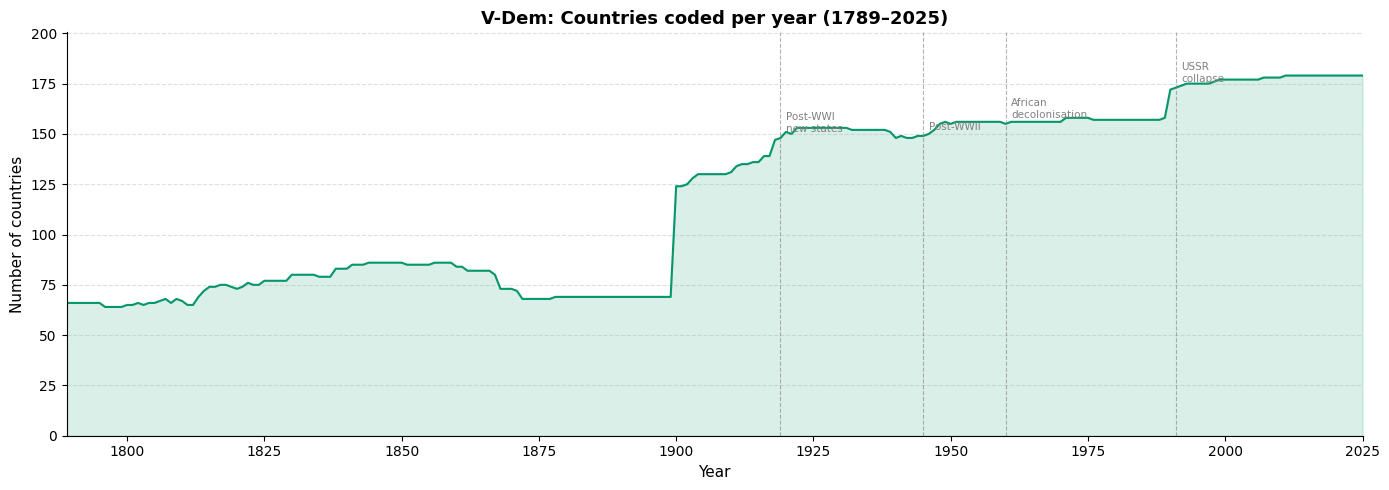

In [1501]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(cpy.index, cpy.values, alpha=0.15, color="#059669")
ax.plot(cpy.index, cpy.values, color="#059669", linewidth=1.5)

milestones = {
    1919: "Post-WWI\nnew states",
    1945: "Post-WWII",
    1960: "African\ndecolonisation",
    1991: "USSR\ncollapse",
}
for yr, label in milestones.items():
    y = cpy.get(yr, cpy.iloc[0])
    ax.axvline(yr, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.text(yr + 1, y + 2, label, fontsize=7.5, color="gray", va="bottom")

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Number of countries", fontsize=11)
ax.set_title("V-Dem: Countries coded per year (1789–2025)", fontsize=13, fontweight="bold")
ax.set_xlim(cpy.index.min(), cpy.index.max())
ax.set_ylim(0, cpy.max() * 1.12)
ax.xaxis.set_major_locator(ticker.MultipleLocator(25))
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


### Scope

In [1502]:
vdem = vdem[(vdem["year"] >= 1971) & (vdem["year"] <= 2018)]
print(f"Shape after scope filter: {vdem.shape[0]:,} rows × {vdem.shape[1]} columns")
print(f"Years: {vdem['year'].min()} – {vdem['year'].max()}")
print(f"Unique countries: {vdem['country_name'].nunique()}")

Shape after scope filter: 8,119 rows × 1908 columns
Years: 1971 – 2018
Unique countries: 182


### Germany Unification

In [1503]:
# DDR (East Germany) has no ISO3 — remap to DEU
vdem.loc[vdem["country_text_id"] == "DDR", "country_text_id"] = "DEU"

# Unified Germany (COWcode=255): copy rows into West Germany (260) and East Germany (265),
# then drop the original unified rows
deu_rows = vdem[vdem["COWcode"] == 255].copy()

deu_west = deu_rows.copy()
deu_west["COWcode"] = 260

deu_east = deu_rows.copy()
deu_east["COWcode"] = 265

vdem = pd.concat([vdem[vdem["COWcode"] != 255], deu_west, deu_east], ignore_index=True)

print(f"DEU rows after remap    : {(vdem['country_text_id'] == 'DEU').sum()}")
print(f"COWcode=255 (unified)   : {(vdem['COWcode'] == 255).sum()}")
print(f"COWcode=260 (West)      : {(vdem['COWcode'] == 260).sum()}")
print(f"COWcode=265 (East/DDR)  : {(vdem['COWcode'] == 265).sum()}")

DEU rows after remap    : 96
COWcode=255 (unified)   : 0
COWcode=260 (West)      : 48
COWcode=265 (East/DDR)  : 48


### Czechoslovakia separation

In [1504]:
# CZE rows (COWcode=315) also represent Slovakia — copy and remap to SVK
svk_rows = vdem[(vdem["COWcode"] == 315) & (vdem["country_text_id"] == "CZE")].copy()
svk_rows["country_text_id"] = "SVK"

vdem = pd.concat([vdem, svk_rows], ignore_index=True)

# COWcode 316/317 are alternative codes for Czechoslovakia/successors — normalize to 315
vdem.loc[vdem["COWcode"].isin([316, 317]), "COWcode"] = 315

print(f"CZE rows (COWcode=315)  : {((vdem['COWcode'] == 315) & (vdem['country_text_id'] == 'CZE')).sum()}")
print(f"SVK rows (COWcode=315)  : {((vdem['COWcode'] == 315) & (vdem['country_text_id'] == 'SVK')).sum()}")
print(f"COWcode=316 remaining   : {(vdem['COWcode'] == 316).sum()}")
print(f"COWcode=317 remaining   : {(vdem['COWcode'] == 317).sum()}")

CZE rows (COWcode=315)  : 48
SVK rows (COWcode=315)  : 48
COWcode=316 remaining   : 0
COWcode=317 remaining   : 0


### Sudan Dissociation

In [1505]:
# SDN rows (COWcode=625, 1971–2010) back-propagated as SSD (South Sudan)
ssd_rows = vdem[
    (vdem["COWcode"] == 625) &
    (vdem["country_text_id"] == "SDN") &
    (vdem["year"] <= 2010)
].copy()
ssd_rows["country_text_id"] = "SSD"

vdem = pd.concat([vdem, ssd_rows], ignore_index=True)

# COWcode=626 (South Sudan) → normalize to 625
vdem.loc[vdem["COWcode"] == 626, "COWcode"] = 625

print(f"SDN rows (COWcode=625)  : {((vdem['COWcode'] == 625) & (vdem['country_text_id'] == 'SDN')).sum()}")
print(f"SSD rows (COWcode=625)  : {((vdem['COWcode'] == 625) & (vdem['country_text_id'] == 'SSD')).sum()}")
print(f"COWcode=626 remaining   : {(vdem['COWcode'] == 626).sum()}")

SDN rows (COWcode=625)  : 48
SSD rows (COWcode=625)  : 48
COWcode=626 remaining   : 0


#### Yemen Unification

In [1506]:
# unified_yemen_rows: COWcode=679 (unified Yemen) → remap to Yemen North (678)
unified_yemen_rows = vdem[vdem["COWcode"] == 679].copy()
vdem.loc[vdem["COWcode"] == 679, "COWcode"] = 678

# Copy unified Yemen rows as Yemen South (680), keep only post-1991 years
yemen_south = unified_yemen_rows.copy()
yemen_south["COWcode"] = 680
yemen_south = yemen_south[yemen_south["year"] >= 1991]

vdem = pd.concat([vdem, yemen_south], ignore_index=True)

# YMD (South Yemen) has no standard ISO3 — remap to YEM
vdem.loc[vdem["country_text_id"] == "YMD", "country_text_id"] = "YEM"

print(f"COWcode=678 (Yemen North) : {(vdem['COWcode'] == 678).sum()}")
print(f"COWcode=680 (Yemen South) : {(vdem['COWcode'] == 680).sum()}")
print(f"COWcode=679 remaining     : {(vdem['COWcode'] == 679).sum()}")
print(f"YMD remaining             : {(vdem['country_text_id'] == 'YMD').sum()}")

COWcode=678 (Yemen North) : 48
COWcode=680 (Yemen South) : 48
COWcode=679 remaining     : 0
YMD remaining             : 0


### Timor-Lest Independence

In [1507]:
vdem.loc[vdem["COWcode"] == 860, "COWcode"] = 850

### Vietnam Unification

In [1508]:
# Unified Vietnam (COWcode=816, 1976+): copy rows as South Vietnam (COWcode=817)
vnm_rows = vdem[(vdem["COWcode"] == 816) & (vdem["year"] >= 1976)].copy()
vnm_rows["COWcode"] = 817

vdem = pd.concat([vdem, vnm_rows], ignore_index=True)

# VDR (Republic of Vietnam / South Vietnam) has no ISO3 — remap to VNM
vdem.loc[vdem["country_text_id"] == "VDR", "country_text_id"] = "VNM"

print(f"COWcode=816 (unified VNM) : {(vdem['COWcode'] == 816).sum()}")
print(f"COWcode=817 (South VNM)   : {(vdem['COWcode'] == 817).sum()}")
print(f"VDR remaining             : {(vdem['country_text_id'] == 'VDR').sum()}")

COWcode=816 (unified VNM) : 48
COWcode=817 (South VNM)   : 48
VDR remaining             : 0


### USSR Dissociation

In [1509]:
SOVIET_SUCCESSORS = {
    "Armenia":     "ARM",
    "Azerbaijan":  "AZE",
    "Belarus":     "BLR",
    "Estonia":     "EST",
    "Georgia":     "GEO",
    "Kazakhstan":  "KAZ",
    "Kyrgyzstan":  "KGZ",
    "Latvia":      "LVA",
    "Lithuania":   "LTU",
    "Moldova":     "MDA",
    "Tajikistan":  "TJK",
    "Turkmenistan": "TKM",
    "Ukraine":     "UKR",
    "Uzbekistan":  "UZB"
}

# Base rows: Russia (COWcode=365) from 1971–1989 — used as USSR proxy for all successors
ussr_base = vdem[
    (vdem["COWcode"] == 365) &
    (vdem["country_text_id"] == "RUS") &
    (vdem["year"] <= 1989)
].copy()

successor_copies = []
for country, iso3 in SOVIET_SUCCESSORS.items():
    rows = ussr_base.copy()
    rows["COWcode"] = 364
    rows["country_text_id"] = iso3
    successor_copies.append(rows)

vdem = pd.concat([vdem] + successor_copies, ignore_index=True)

# Update each successor's own existing rows to COWcode=364
successor_iso3s = list(SOVIET_SUCCESSORS.values())
vdem.loc[vdem["country_text_id"].isin(successor_iso3s), "COWcode"] = 364

print(f"COWcode=364 rows        : {(vdem['COWcode'] == 364).sum()}")
for iso3 in successor_iso3s:
    n = ((vdem["COWcode"] == 364) & (vdem["country_text_id"] == iso3)).sum()
    print(f"  {iso3}: {n} rows")

# Update Russia COWcode to 364 as well, since it represents USSR in 1971–1989 and post-1991 Russia is a direct continuation of that entity.
vdem.loc[vdem["country_text_id"] == "RUS", "COWcode"] = 364

COWcode=364 rows        : 672
  ARM: 48 rows
  AZE: 48 rows
  BLR: 48 rows
  EST: 48 rows
  GEO: 48 rows
  KAZ: 48 rows
  KGZ: 48 rows
  LVA: 48 rows
  LTU: 48 rows
  MDA: 48 rows
  TJK: 48 rows
  TKM: 48 rows
  UKR: 48 rows
  UZB: 48 rows


### Yugoslavia Separation

In [1510]:
# Normalize all Yugoslav-era COW codes to 345 (Yugoslavia/Serbia)
vdem.loc[vdem["COWcode"].isin([346, 347, 349, 344, 341, 343]), "COWcode"] = 345

# Use only the SRB series as the Yugoslavia template (avoids picking up successor rows)
yugoslavia_rows = vdem[(vdem["COWcode"] == 345) & (vdem["country_text_id"] == "SRB")].copy()

# Each successor: back-propagate Yugoslavia rows for years before independence
YUG_SUCCESSORS = {
    "SVN": 1989,
    "HRV": 1991,
    "BIH": 1992,
    "MNE": 1998,
    "MKD": 1991,
    "XKX": 1999,
}

successor_copies = []
for iso3, since_year in YUG_SUCCESSORS.items():
    rows = yugoslavia_rows[yugoslavia_rows["year"] < since_year].copy()
    rows["country_text_id"] = iso3
    successor_copies.append(rows)
    print(f"  {iso3} (since {since_year}): {len(rows)} rows (1971–{since_year - 1})")

vdem = pd.concat([vdem] + successor_copies, ignore_index=True)

print(f"\nCOWcode=345 total rows  : {(vdem['COWcode'] == 345).sum()}")
for iso3 in ["SRB"] + list(YUG_SUCCESSORS.keys()):
    n = ((vdem["COWcode"] == 345) & (vdem["country_text_id"] == iso3)).sum()
    print(f"  {iso3}: {n} rows")

  SVN (since 1989): 18 rows (1971–1988)
  HRV (since 1991): 20 rows (1971–1990)
  BIH (since 1992): 21 rows (1971–1991)
  MNE (since 1998): 27 rows (1971–1997)
  MKD (since 1991): 20 rows (1971–1990)
  XKX (since 1999): 28 rows (1971–1998)

COWcode=345 total rows  : 336
  SRB: 48 rows
  SVN: 48 rows
  HRV: 48 rows
  BIH: 48 rows
  MNE: 48 rows
  MKD: 48 rows
  XKX: 48 rows


### Remove Other Countries

In [1511]:
to_remove = ["PSE","PSG","SML","HKG","ZZB"]  # Palestine/West Bank, Palestine/Gaza, Somaliland, Hong Kong, Zanzibar

vdem = vdem[~vdem["country_text_id"].isin(to_remove)]
print(f"Removed: {to_remove}")
print(f"Remaining rows: {len(vdem):,}")

Removed: ['PSE', 'PSG', 'SML', 'HKG', 'ZZB']
Remaining rows: 8,496


### Identifier

In [1512]:
vdem["ts_id"] = vdem["COWcode"].astype(int).astype(str) + "_" + vdem["country_text_id"]

vdem = vdem.sort_values(["ts_id", "year"]).reset_index(drop=True)

print(f"Unique ts_ids: {vdem['ts_id'].nunique()}")
print(vdem[["ts_id", "COWcode", "country_text_id"]].drop_duplicates().head(10).to_string(index=False))

Unique ts_ids: 177
  ts_id  COWcode country_text_id
100_COL    100.0             COL
101_VEN    101.0             VEN
110_GUY    110.0             GUY
115_SUR    115.0             SUR
130_ECU    130.0             ECU
135_PER    135.0             PER
140_BRA    140.0             BRA
145_BOL    145.0             BOL
150_PRY    150.0             PRY
155_CHL    155.0             CHL


/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_27647/435789383.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  vdem["ts_id"] = vdem["COWcode"].astype(int).astype(str) + "_" + vdem["country_text_id"]


### Export

In [1513]:
import pycountry

valid_iso3 = {c.alpha_3 for c in pycountry.countries}

unique_ids = vdem[["country_text_id", "country_name"]].drop_duplicates().sort_values("country_text_id")
no_iso3 = unique_ids[~unique_ids["country_text_id"].isin(valid_iso3)]

print(f"Non-ISO3 country_text_id values ({len(no_iso3)}):")
for _, row in no_iso3.iterrows():
    print(f"  {row['country_text_id']!r:8s}  {row['country_name']}")

Non-ISO3 country_text_id values (2):
  'XKX'     Serbia
  'XKX'     Kosovo


In [1514]:
import os

os.makedirs("processed-datasets/v-dem", exist_ok=True)

vdem_cols = [
    # Identifiers
    "ts_id", "COWcode", "country_text_id", "country_id", "country_name", "year",
    # Democracy indices (treatment variables)
    "v2x_polyarchy", "v2x_libdem", "v2x_partipdem", "v2x_delibdem", "v2x_egaldem",
    # Women's rights outcomes
    "v2x_gender", "v2x_gencl", "v2x_gencs", "v2x_genpp",
    "v2xpe_exlgender", "v2lgfemleg",
    # Component women's indicators
    "v2cldmovew", "v2clslavef", "v2clprptyw", "v2cldiscw",
    "v2pepwrgen", "v2peapsgen", "v2peasjgen", "v2peasbgen",
    "v2csgender", "v2mefemjrn",
    # Mechanisms
    "v2x_cspart", "v2x_frassoc_thick", "v2x_freexp_altinf",
    "v2x_suffr", "v2xlg_legcon", "v2x_jucon",
    "v2xeg_eqprotec", "v2xeg_eqaccess",
    # Controls
    "v2x_corr", "v2x_rule", "v2xeg_eqdr",
]

available_cols = [c for c in vdem_cols if c in vdem.columns]
missing_cols = [c for c in vdem_cols if c not in vdem.columns]
if missing_cols:
    print(f"WARNING — columns not found: {missing_cols}")

out_vdem = vdem[available_cols].sort_values(["ts_id", "year"]).copy()
out_vdem.to_csv("processed-datasets/v-dem/vdem.csv", index=False)
print(f"Saved {len(out_vdem):,} rows × {len(available_cols)} columns → processed-datasets/v-dem/vdem.csv")
out_vdem.head(5)

Saved 8,496 rows × 38 columns → processed-datasets/v-dem/vdem.csv


,ts_id,COWcode,country_text_id,country_id,country_name,year,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,...,v2x_frassoc_thick,v2x_freexp_altinf,v2x_suffr,v2xlg_legcon,v2x_jucon,v2xeg_eqprotec,v2xeg_eqaccess,v2x_corr,v2x_rule,v2xeg_eqdr
0,100_COL,100.0,COL,15,Colombia,1971,0.361,0.258,0.138,0.144,...,0.463,0.596,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
1,100_COL,100.0,COL,15,Colombia,1972,0.369,0.261,0.140,0.146,...,0.463,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
2,100_COL,100.0,COL,15,Colombia,1973,0.369,0.261,0.140,0.146,...,0.463,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
3,100_COL,100.0,COL,15,Colombia,1974,0.411,0.277,0.155,0.167,...,0.538,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
4,100_COL,100.0,COL,15,Colombia,1975,0.445,0.300,0.168,0.271,...,0.609,0.646,1.0,0.728,0.598,0.155,0.186,0.485,0.536,0.277


# Merge Datasets

In [1515]:
polity_df = pd.read_csv("processed-datasets/polity/polity5.csv")
vdem_df   = pd.read_csv("processed-datasets/v-dem/vdem.csv")

# Polity features (prefixed p_)
polity_cols = [
    "orig_ccode", "orig_country", "country", "curr_iso3", "curr_country", "year",
    "polity2", "democ", "autoc",
    "exrec", "exconst", "polcomp",
    "d5", "sf", "regtrans",
]
polity_features = ["polity2", "democ", "autoc", "exrec", "exconst", "polcomp", "d5", "sf", "regtrans"]

polity_renamed = polity_df[["ts_id"] + polity_cols].rename(
    columns={f: f"p_{f}" for f in polity_features}
)

# V-Dem features (prefixed v_)
vdem_features = [
    "v2x_polyarchy", "v2x_libdem", "v2x_partipdem", "v2x_delibdem", "v2x_egaldem",
    "v2x_gender", "v2x_gencl", "v2x_gencs", "v2x_genpp",
    "v2xpe_exlgender", "v2lgfemleg",
    "v2cldmovew", "v2clslavef", "v2clprptyw", "v2cldiscw",
    "v2pepwrgen", "v2peapsgen", "v2peasjgen", "v2peasbgen",
    "v2csgender", "v2mefemjrn",
    "v2x_cspart", "v2x_frassoc_thick", "v2x_freexp_altinf",
    "v2x_suffr", "v2xlg_legcon", "v2x_jucon",
    "v2xeg_eqprotec", "v2xeg_eqaccess",
    "v2x_corr", "v2x_rule", "v2xeg_eqdr",
]
available_vdem_features = [f for f in vdem_features if f in vdem_df.columns]

vdem_renamed = vdem_df[["ts_id", "year", "country_name"] + available_vdem_features].rename(
    columns={f: f"v_{f}" for f in available_vdem_features}
)

# Outer join on ts_id + year
merged = pd.merge(
    polity_renamed,
    vdem_renamed,
    on=["ts_id", "year"],
    how="outer",
).sort_values(["ts_id", "year"]).reset_index(drop=True)

# Fill missing "country" from V-Dem country_name
merged["country"] = merged["country"].fillna(merged["country_name"])
merged = merged.drop(columns=["country_name"])

os.makedirs("processed-datasets/merged", exist_ok=True)
merged.to_csv("processed-datasets/merged/democracy.csv", index=False)

print(f"Polity rows  : {len(polity_df):,}")
print(f"V-Dem rows   : {len(vdem_df):,}")
print(f"Merged rows  : {len(merged):,}  ({merged['ts_id'].nunique()} ts_ids)")
print(f"Columns      : {len(merged.columns)}")
merged.head(5)

Polity rows  : 8,038
V-Dem rows   : 8,496
Merged rows  : 8,561  (179 ts_ids)
Columns      : 48


,ts_id,orig_ccode,orig_country,country,curr_iso3,curr_country,year,p_polity2,p_democ,p_autoc,...,v_v2x_frassoc_thick,v_v2x_freexp_altinf,v_v2x_suffr,v_v2xlg_legcon,v_v2x_jucon,v_v2xeg_eqprotec,v_v2xeg_eqaccess,v_v2x_corr,v_v2x_rule,v_v2xeg_eqdr
0,100_COL,100.0,Colombia,Colombia,COL,Colombia,1971,7.0,7.0,0.0,...,0.463,0.596,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
1,100_COL,100.0,Colombia,Colombia,COL,Colombia,1972,7.0,7.0,0.0,...,0.463,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
2,100_COL,100.0,Colombia,Colombia,COL,Colombia,1973,7.0,7.0,0.0,...,0.463,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
3,100_COL,100.0,Colombia,Colombia,COL,Colombia,1974,8.0,8.0,0.0,...,0.538,0.632,1.0,0.704,0.574,0.155,0.186,0.485,0.530,0.259
4,100_COL,100.0,Colombia,Colombia,COL,Colombia,1975,8.0,8.0,0.0,...,0.609,0.646,1.0,0.728,0.598,0.155,0.186,0.485,0.536,0.277
